<a href="https://colab.research.google.com/github/Santhiya-C01/Chocolate_Sales_Analysis.ipynb/blob/main/Chocolate_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chocolate Sales Analysis

In [ ]:
#import csv file

from google.colab import files
uploaded = files.upload()



Saving Chocolate Sales Analysis.csv to Chocolate Sales Analysis (1).csv


In [ ]:
import pandas as pd
df = pd.read_csv('Chocolate Sales Analysis (1).csv')


# Sales Analysis

In [ ]:
#Total sales amount

df['Amount'] = df['Amount'].replace({r'\$': '', ',': ''}, regex=True).astype(float)
total_sales_amount = df['Amount'].sum()
print(f"Total Sales Amount: ${total_sales_amount:,.2f}")

Total Sales Amount: $19,791,571.86


In [ ]:
# Calculate the average sales amount per transaction

average_sales_amount = df['Amount'].mean()
print(f"Average Sales Amount per Transaction: ${average_sales_amount:,.2f}")

Average Sales Amount per Transaction: $6,030.34


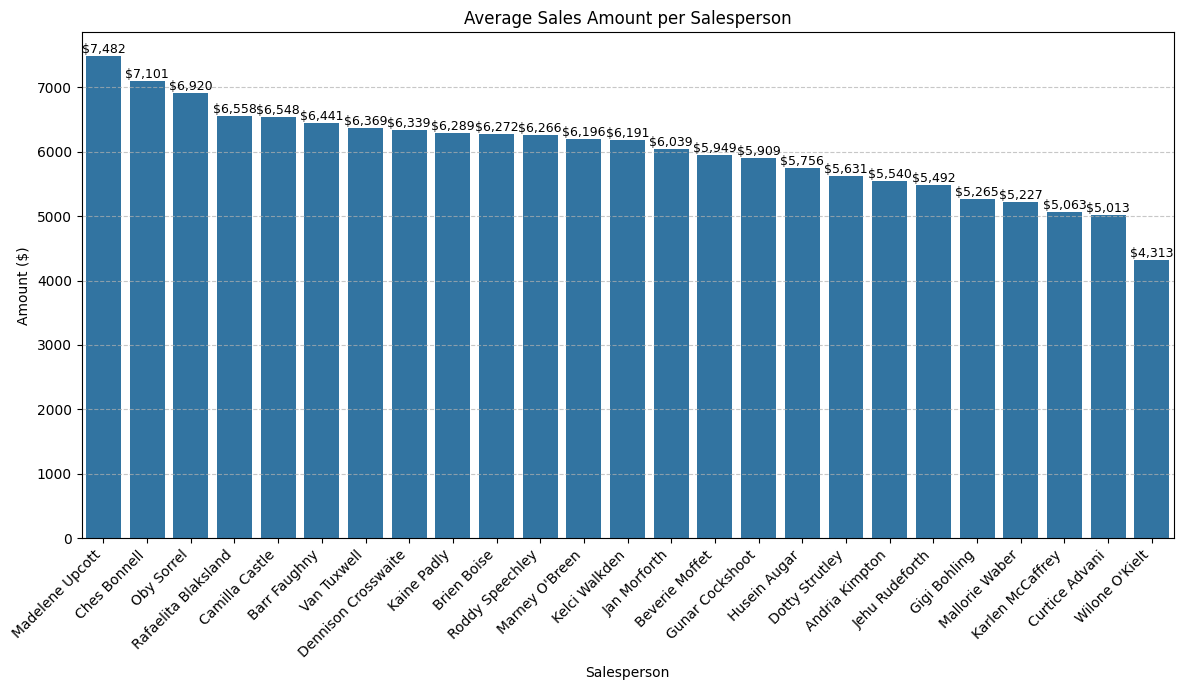

In [ ]:
# chart for average sales amount per transaction

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure average_sales_by_salesperson is available (assuming it's calculated in a preceding cell)
# If not, you might need to add: average_sales_by_salesperson = df.groupby('Sales Person')['Amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=average_sales_by_salesperson.index,
    y=average_sales_by_salesperson.values
)

# Add labels on top of bars
for i, value in enumerate(average_sales_by_salesperson.values):
    ax.text(
        i,
        value,
        f'${value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Average Sales Amount per Salesperson')
plt.ylabel('Amount ($)')
plt.xlabel('Salesperson')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#Highest and lowest sales amount

highest_sale = df['Amount'].max()
lowest_sale = df['Amount'].min()
print(f"Highest Sale Amount: ${highest_sale:,.2f}")
print(f"Lowest Sale Amount: ${lowest_sale:,.2f}")


Highest Sale Amount: $26,170.95
Lowest Sale Amount: $7.00


In [ ]:
# Total number of transactions

total_transactions = len(df)
print(f"Total Number of Transactions: {total_transactions}")

Total Number of Transactions: 3282


In [ ]:
#Total number of boxes shipped

total_boxes_shipped = df['Boxes Shipped'].sum()
print(f"Total Number of Boxes Shipped: {total_boxes_shipped:,.0f}")

Total Number of Boxes Shipped: 540,437


# Product Analysis

In [ ]:
# Calculate total sales for each product

total_sales_by_product = df.groupby('Product')['Amount'].sum()

# Find the product with the highest sales revenue
highest_revenue_product = total_sales_by_product.idxmax()
highest_revenue_amount = total_sales_by_product.max()

print(f"The highest sales revenue is '{highest_revenue_product}' with a total of ${highest_revenue_amount:,.2f}.")

The highest sales revenue is 'Smooth Sliky Salty' with a total of $1,120,201.09.


In [ ]:
# Calculate total boxes shipped for each product

total_boxes_by_product = df.groupby('Product')['Boxes Shipped'].sum()

# Find the product with the most boxes sold
most_boxes_product = total_boxes_by_product.idxmax()
most_boxes_amount = total_boxes_by_product.max()

print(f"The product that sold the most boxes is '{most_boxes_product}' with a total of {most_boxes_amount:,.0f} boxes.")

The product that sold the most boxes is '50% Dark Bites' with a total of 29,810 boxes.


In [ ]:
#Top 10 products by sales

top_10_products_by_sales = total_sales_by_product.sort_values(ascending=False).head(10)

print("Top 10 Products by Sales Revenue:")
for product, sales in top_10_products_by_sales.items():
    print(f"- {product}: ${sales:,.2f}")

Top 10 Products by Sales Revenue:
- Smooth Sliky Salty: $1,120,201.09
- 50% Dark Bites: $1,087,659.35
- White Choc: $1,054,257.00
- Peanut Butter Cubes: $1,036,591.09
- Eclairs: $996,947.96
- 99% Dark & Pure: $960,033.45
- 85% Dark Bars: $955,268.24
- Organic Choco Syrup: $945,345.73
- Spicy Special Slims: $938,131.69
- Mint Chip Choco: $904,989.55


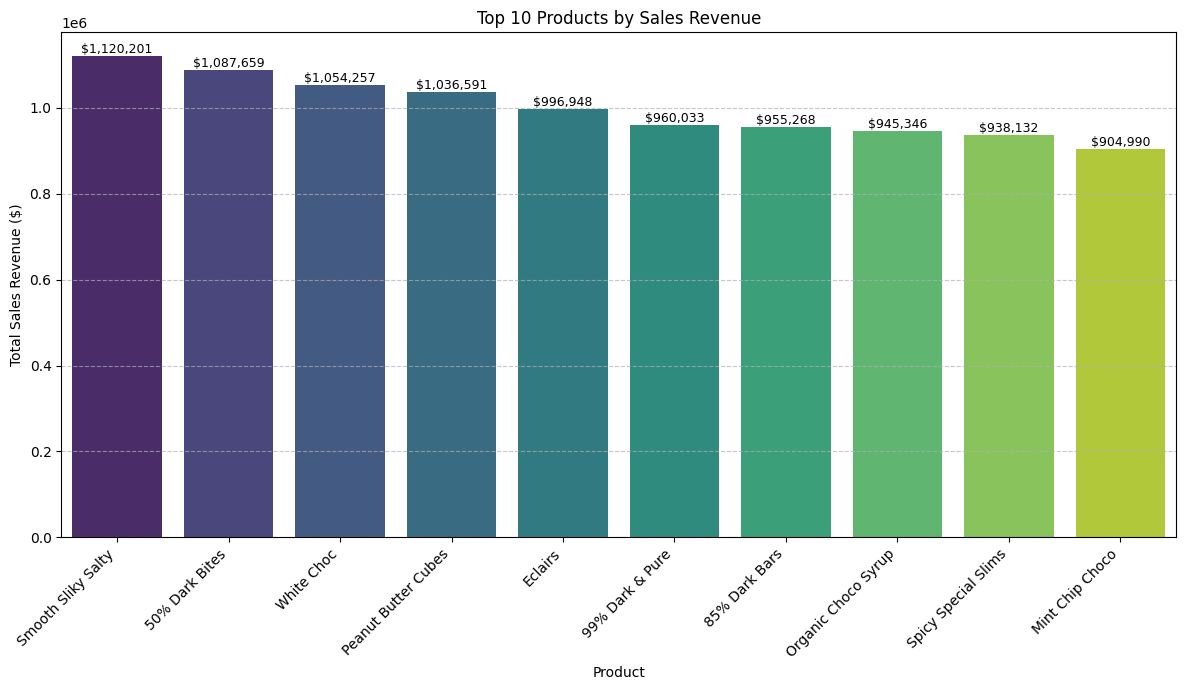

In [ ]:
# Chart for Top 10 products by sales

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=top_10_products_by_sales.index,
    y=top_10_products_by_sales.values,
    palette='viridis',
    hue=top_10_products_by_sales.index, # Use hue to apply palette color to each bar and avoid FutureWarning
    legend=False
)

# Add values on top of bars
for i, value in enumerate(top_10_products_by_sales.values):
    ax.text(
        i,
        value,
        f'${value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Top 10 Products by Sales Revenue')
plt.ylabel('Total Sales Revenue ($)')
plt.xlabel('Product')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Product with the lowest sales revenue

lowest_revenue_product = total_sales_by_product.idxmin()
lowest_revenue_amount = total_sales_by_product.min()

print(f"The product that generated the lowest sales revenue is '{lowest_revenue_product}' with a total of ${lowest_revenue_amount:,.2f}.")

The product that generated the lowest sales revenue is '70% Dark Bites' with a total of $677,346.22.


In [ ]:
# Calculate the percentage of total sales for each product

percentage_of_total_sales = (total_sales_by_product / total_sales_amount) * 100

# Sort in descending order for better readability
percentage_of_total_sales = percentage_of_total_sales.sort_values(ascending=False)

print("Percentage of Total Sales by Product:")
for product, percentage in percentage_of_total_sales.items():
    print(f"- {product}: {percentage:,.2f}%")

Percentage of Total Sales by Product:
- Smooth Sliky Salty: 5.66%
- 50% Dark Bites: 5.50%
- White Choc: 5.33%
- Peanut Butter Cubes: 5.24%
- Eclairs: 5.04%
- 99% Dark & Pure: 4.85%
- 85% Dark Bars: 4.83%
- Organic Choco Syrup: 4.78%
- Spicy Special Slims: 4.74%
- Mint Chip Choco: 4.57%
- Almond Choco: 4.50%
- Manuka Honey Choco: 4.47%
- Milk Bars: 4.38%
- Raspberry Choco: 4.27%
- After Nines: 4.23%
- Fruit & Nut Bars: 4.19%
- Orange Choco: 4.16%
- Drinking Coco: 4.15%
- Baker's Choco Chips: 4.04%
- Choco Coated Almonds: 3.91%
- Caramel Stuffed Bars: 3.75%
- 70% Dark Bites: 3.42%


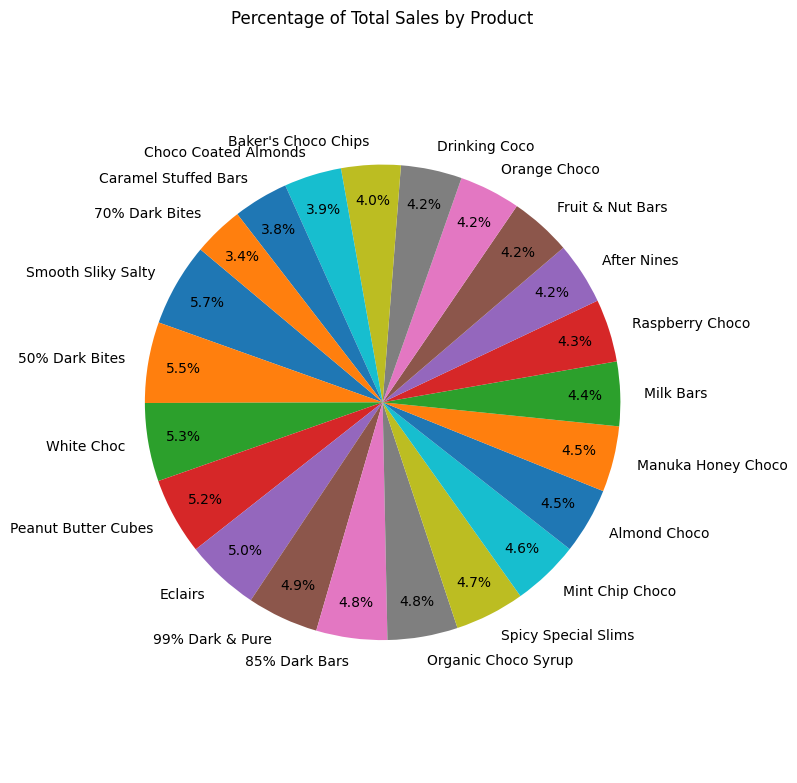

In [ ]:
#percentage of total sales comes from each product

import matplotlib.pyplot as plt
import seaborn as sns

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(percentage_of_total_sales, labels=percentage_of_total_sales.index, autopct='%1.1f%%', startangle=140, pctdistance=0.85)
plt.title('Percentage of Total Sales by Product')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Country Analysis


In [ ]:
#country generated the highest sales

total_sales_by_country = df.groupby('Country')['Amount'].sum()

highest_sales_country = total_sales_by_country.idxmax()
highest_sales_amount = total_sales_by_country.max()

print(f"The country with the highest total sales is '{highest_sales_country}' with a total of ${highest_sales_amount:,.2f}.")

The country with the highest total sales is 'Australia' with a total of $3,646,444.35.


In [ ]:
#country shipped the most boxes

total_boxes_by_country = df.groupby('Country')['Boxes Shipped'].sum()

highest_boxes_country = total_boxes_by_country.idxmax()
highest_boxes_amount = total_boxes_by_country.max()

print(f"The country that shipped the most boxes is '{highest_boxes_country}' with a total of {highest_boxes_amount:,.0f} boxes.")

The country that shipped the most boxes is 'Australia' with a total of 99,618 boxes.


In [ ]:
#Average sales per country

print(average_sales_per_country)

Country
UK             6302.226404
USA            6171.057896
India          6057.483388
Australia      5929.177805
New Zealand    5864.458651
Canada         5863.801238
Name: Amount, dtype: float64


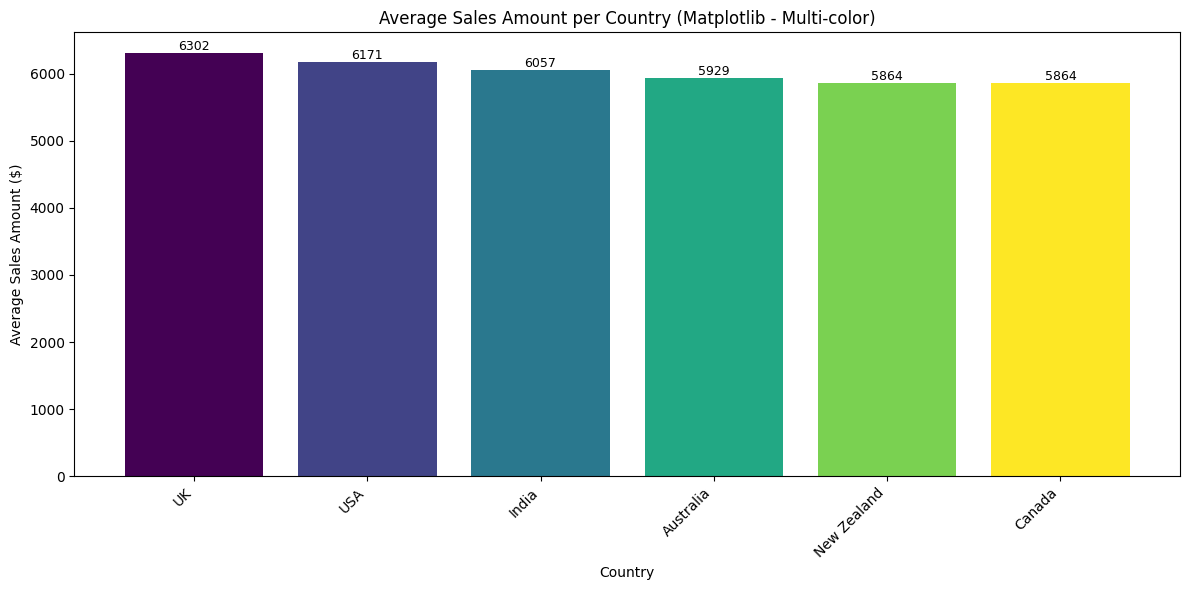

In [ ]:
# Bar chart for Average sales per country
import matplotlib.pyplot as plt
import numpy as np

# Create a bar chart using matplotlib with different colors
plt.figure(figsize=(12, 6))

# Generate a list of colors using a colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(average_sales_per_country)))

bars = plt.bar(
    average_sales_per_country.index,
    average_sales_per_country.values,
    color=colors
)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Average Sales Amount per Country (Matplotlib - Multi-color)')
plt.xlabel('Country')
plt.ylabel('Average Sales Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Rank countries based on total sales

ranked_countries_by_sales = total_sales_by_country.sort_values(ascending=False)

print("Countries Ranked by Total Sales:")
for country, sales in ranked_countries_by_sales.items():
    print(f"- {country}: ${sales:,.2f}")

Countries Ranked by Total Sales:
- Australia: $3,646,444.35
- UK: $3,365,388.90
- India: $3,343,730.83
- USA: $3,313,858.09
- Canada: $3,078,495.65
- New Zealand: $3,043,654.04


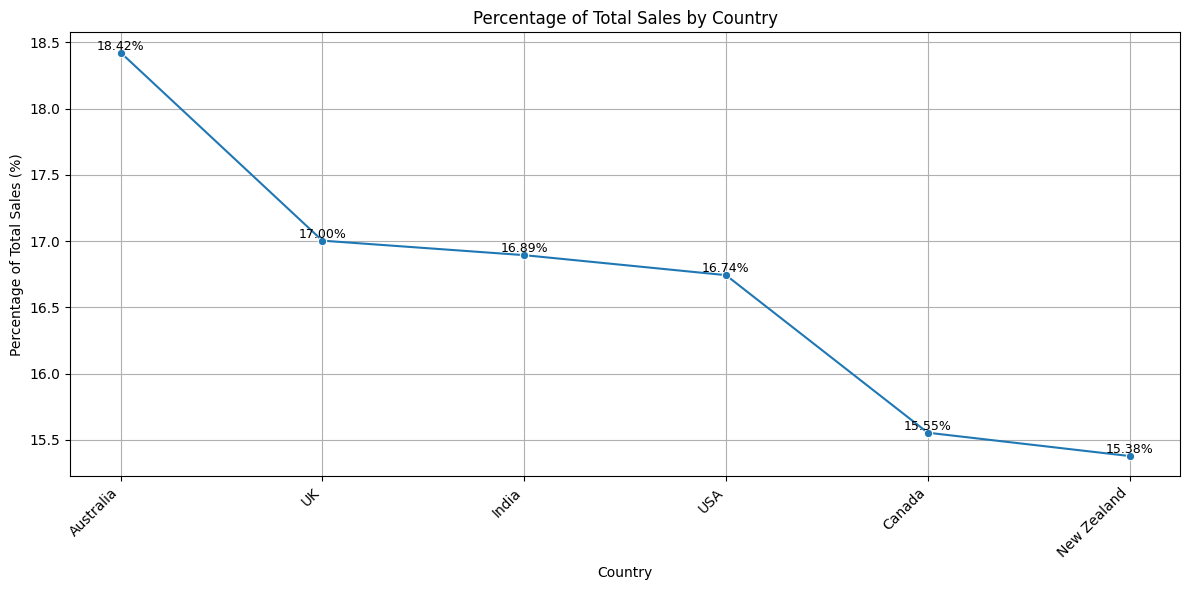

In [ ]:
## Calculate the percentage of total sales for each country
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the data for better visualization
percentage_of_total_sales_by_country_sorted = percentage_of_total_sales_by_country.sort_values(ascending=False)

# Create line chart
plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    x=percentage_of_total_sales_by_country_sorted.index,
    y=percentage_of_total_sales_by_country_sorted.values,
    marker='o'
)

# Add percentage labels
for i, value in enumerate(percentage_of_total_sales_by_country_sorted.values):
    plt.text(
        i,
        value,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Percentage of Total Sales by Country')
plt.xlabel('Country')
plt.ylabel('Percentage of Total Sales (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(True)

plt.tight_layout()
plt.show()

# Salesperson Analysis


In [ ]:
# Calculate total sales for each salesperson

total_sales_by_salesperson = df.groupby('Sales Person')['Amount'].sum()

# Find the salesperson with the highest total sales
top_salesperson = total_sales_by_salesperson.idxmax()
top_sales_amount = total_sales_by_salesperson.max()

print(f"The top-performing salesperson is '{top_salesperson}' with total sales of ${top_sales_amount:,.2f}.")

The top-performing salesperson is 'Ches Bonnell' with total sales of $1,022,599.96.


In [ ]:
# Calculate total sales for each salesperson

total_sales_by_salesperson = df.groupby('Sales Person')['Amount'].sum()

# Find the salesperson with the highest total sales
top_salesperson = total_sales_by_salesperson.idxmax()
top_sales_amount = total_sales_by_salesperson.max()

print(f"The top-performing salesperson is '{top_salesperson}' with total sales of ${top_sales_amount:,.2f}.")

The top-performing salesperson is 'Ches Bonnell' with total sales of $1,022,599.96.


In [ ]:
# The country that shipped the most boxes

total_boxes_by_country = df.groupby('Country')['Boxes Shipped'].sum()

highest_boxes_country = total_boxes_by_country.idxmax()
highest_boxes_amount = total_boxes_by_country.max()

print(f"The country that shipped the most boxes is '{highest_boxes_country}' with a total of {highest_boxes_amount:,.0f} boxes.")

# The product that sold the most boxes

total_boxes_by_product = df.groupby('Product')['Boxes Shipped'].sum()

most_boxes_product = total_boxes_by_product.idxmax()
most_boxes_amount = total_boxes_by_product.max()

print(f"The product that sold the most boxes is '{most_boxes_product}' with a total of {most_boxes_amount:,.0f} boxes.")

The country that shipped the most boxes is 'Australia' with a total of 99,618 boxes.
The product that sold the most boxes is '50% Dark Bites' with a total of 29,810 boxes.


In [ ]:
# Calculate the average sales amount per salesperson

average_sales_by_salesperson = df.groupby('Sales Person')['Amount'].mean().sort_values(ascending=False)

print("Average Sales Amount per Salesperson:")
for salesperson, avg_sales in average_sales_by_salesperson.items():
    print(f"- {salesperson}: ${avg_sales:,.2f}")

Average Sales Amount per Salesperson:
- Madelene Upcott: $7,481.69
- Ches Bonnell: $7,101.39
- Oby Sorrel: $6,919.76
- Rafaelita Blaksland: $6,557.50
- Camilla Castle: $6,548.05
- Barr Faughny: $6,440.52
- Van Tuxwell: $6,368.79
- Dennison Crosswaite: $6,339.11
- Kaine Padly: $6,289.35
- Brien Boise: $6,272.49
- Roddy Speechley: $6,266.35
- Marney O'Breen: $6,195.76
- Kelci Walkden: $6,190.92
- Jan Morforth: $6,039.19
- Beverie Moffet: $5,949.48
- Gunar Cockshoot: $5,909.17
- Husein Augar: $5,755.70
- Dotty Strutley: $5,630.57
- Andria Kimpton: $5,540.30
- Jehu Rudeforth: $5,492.29
- Gigi Bohling: $5,264.51
- Mallorie Waber: $5,226.86
- Karlen McCaffrey: $5,062.64
- Curtice Advani: $5,013.03
- Wilone O'Kielt: $4,313.35


In [ ]:
# Rank salespersons based on total sales revenue

ranked_salespersons_by_revenue = total_sales_by_salesperson.sort_values(ascending=False)

print("Salespersons Ranked by Total Sales Revenue:")
for salesperson, revenue in ranked_salespersons_by_revenue.items():
    print(f"- {salesperson}: ${revenue:,.2f}")

Salespersons Ranked by Total Sales Revenue:
- Ches Bonnell: $1,022,599.96
- Oby Sorrel: $1,017,204.12
- Madelene Upcott: $1,010,028.72
- Kelci Walkden: $1,002,929.10
- Brien Boise: $997,326.48
- Van Tuxwell: $974,425.09
- Dennison Crosswaite: $931,849.57
- Beverie Moffet: $892,421.37
- Kaine Padly: $849,062.76
- Marney O'Breen: $836,427.63
- Barr Faughny: $830,826.91
- Roddy Speechley: $808,359.58
- Gunar Cockshoot: $762,283.43
- Gigi Bohling: $742,296.51
- Karlen McCaffrey: $713,832.64
- Jehu Rudeforth: $708,505.03
- Jan Morforth: $706,585.50
- Curtice Advani: $691,797.92
- Rafaelita Blaksland: $668,865.45
- Husein Augar: $656,149.73
- Andria Kimpton: $648,214.81
- Mallorie Waber: $642,903.33
- Camilla Castle: $628,613.13
- Dotty Strutley: $608,101.17
- Wilone O'Kielt: $439,961.92


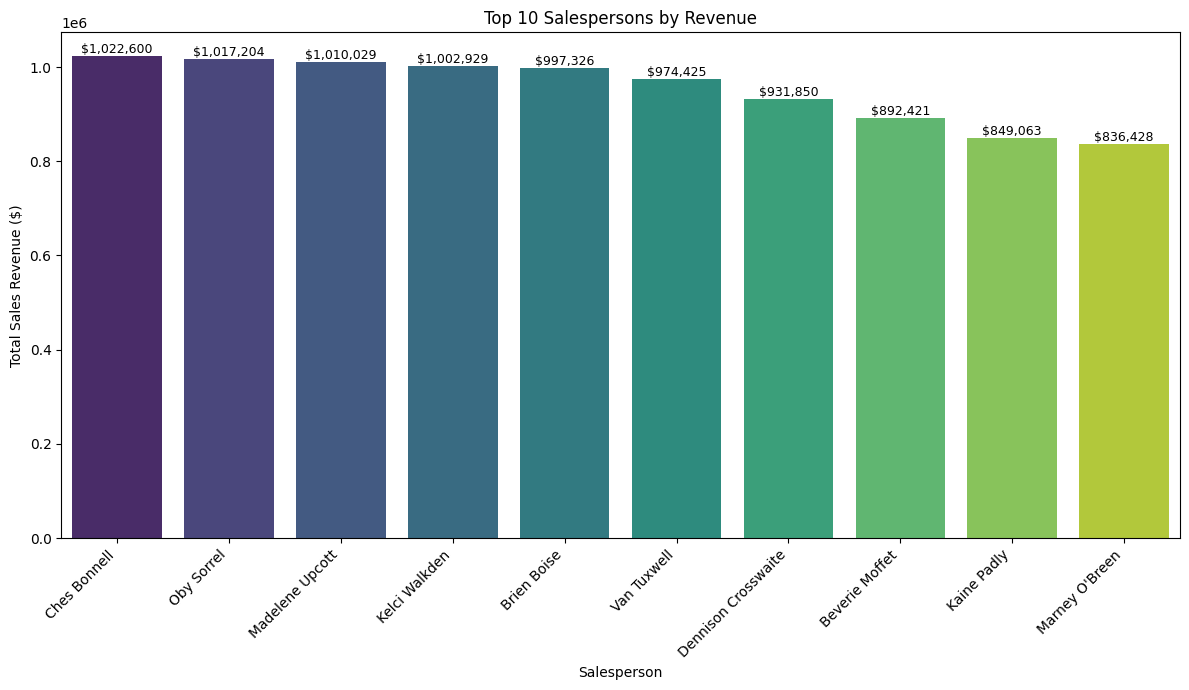

In [ ]:
##Chart for top 10 salespersons by revenue
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 salespersons by revenue
top_10_salespersons_by_revenue = ranked_salespersons_by_revenue.head(10)

# Create a bar chart
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=top_10_salespersons_by_revenue.index,
    y=top_10_salespersons_by_revenue.values,
    palette='viridis',
    hue=top_10_salespersons_by_revenue.index,
    legend=False
)

# Add values on top of bars
for i, value in enumerate(top_10_salespersons_by_revenue.values):
    ax.text(
        i,
        value,
        f'${value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Top 10 Salespersons by Revenue')
plt.xlabel('Salesperson')
plt.ylabel('Total Sales Revenue ($)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Time based Analysis


In [ ]:
#the monthly sales trends

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Month'] = df['Date'].dt.month
monthly_sales = df.groupby('Month')['Amount'].sum()
display(monthly_sales)

,Amount
Month,
1,2868712.59
2,2232096.90
3,2404769.29
4,2161927.22
5,2415750.57
6,2773931.94
7,2567532.29
8,2366851.06


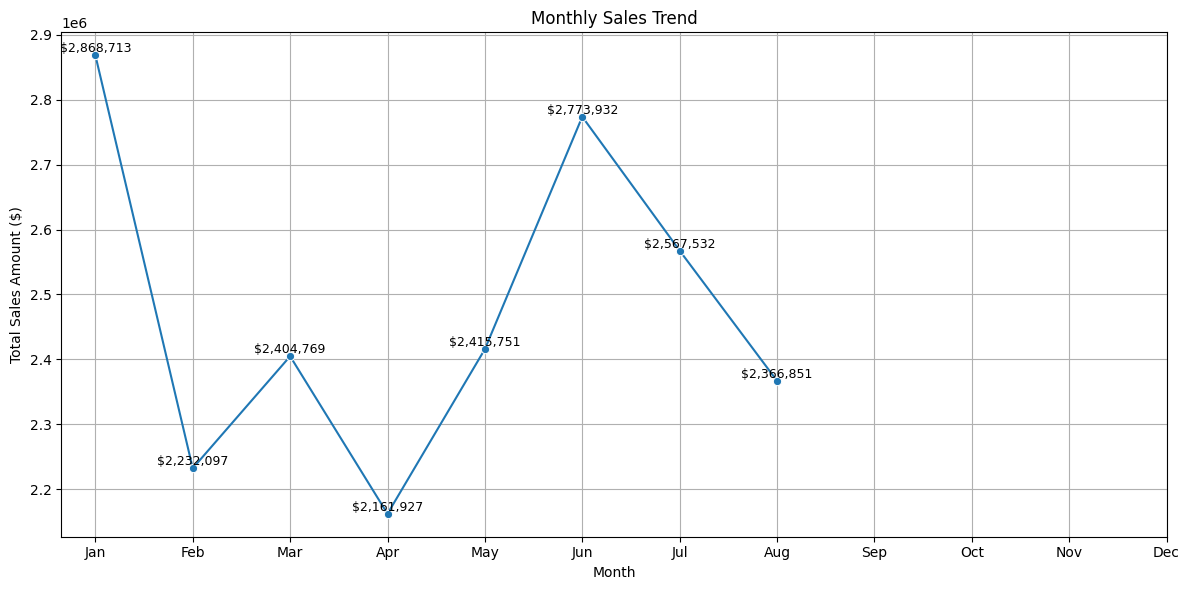

In [ ]:
#Visualization for the monthly sales trends

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker='o'
)

# Add values on each point
for x, y in zip(monthly_sales.index, monthly_sales.values):
    plt.text(
        x,
        y,
        f'${y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount ($)')
plt.xticks(
    range(1, 13),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Identify the month with the highest sales

highest_sales_month = monthly_sales.idxmax()
highest_sales_amount_month = monthly_sales.max()

# Map the month number to month name for better readability
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
highest_sales_month_name = month_names[highest_sales_month - 1]

print(f"The month with the highest sales is {highest_sales_month_name} with a total of ${highest_sales_amount_month:,.2f}.")

The month with the highest sales is Jan with a total of $2,868,712.59.


In [ ]:
#which year generated most revenue

df['Year'] = df['Date'].dt.year
yearly_sales = df.groupby('Year')['Amount'].sum()
display(yearly_sales)


highest_sales_year = yearly_sales.idxmax()
highest_sales_amount_year = yearly_sales.max()
print(f"The year with the highest sales revenue is {highest_sales_year} with a total of ${highest_sales_amount_year:,.2f}.")

,Amount
Year,
2022,6183625.00
2023,6643377.96
2024,6964568.90


The year with the highest sales revenue is 2024 with a total of $6,964,568.90.


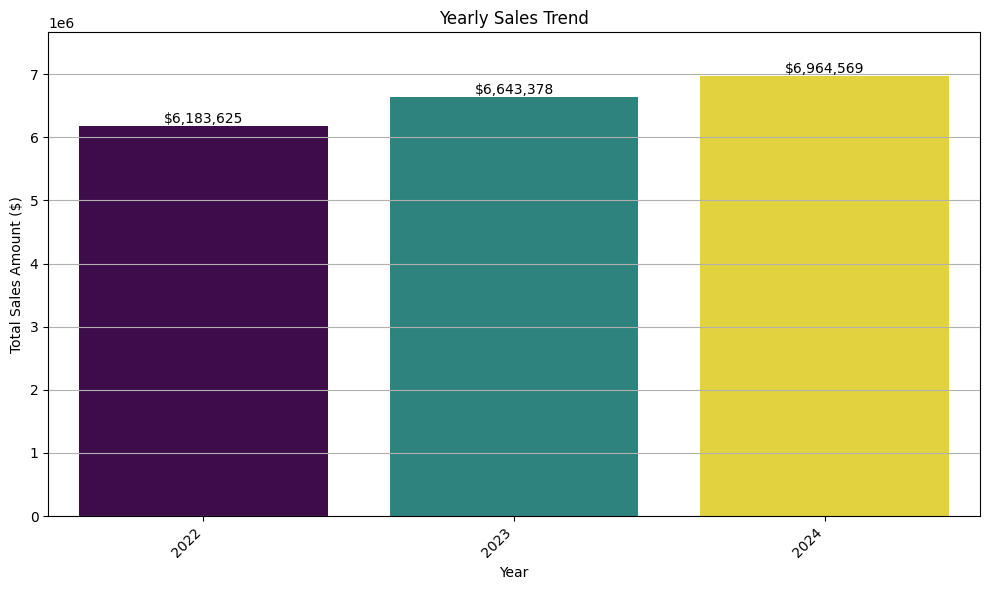

In [ ]:
#Chart for yearly sales trend

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=yearly_sales.index,
    y=yearly_sales.values,
    palette='viridis',
    hue=yearly_sales.index,
    legend=False
)

# Add values on top of bars
for i, value in enumerate(yearly_sales.values):
    ax.text(
        i,
        value,
        f'${value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

# Add some extra space above bars
plt.ylim(0, yearly_sales.max() * 1.1)

plt.tight_layout()
plt.show()

In [ ]:
#Compare Year-over-Year (YoY) sales growth.

yoy_growth = yearly_sales.pct_change() * 100
yoy_growth = yoy_growth.dropna()
print("Year-over-Year Sales Growth (%):")
display(yoy_growth)

Year-over-Year Sales Growth (%):


,Amount
Year,
2023,7.435007
2024,4.834753


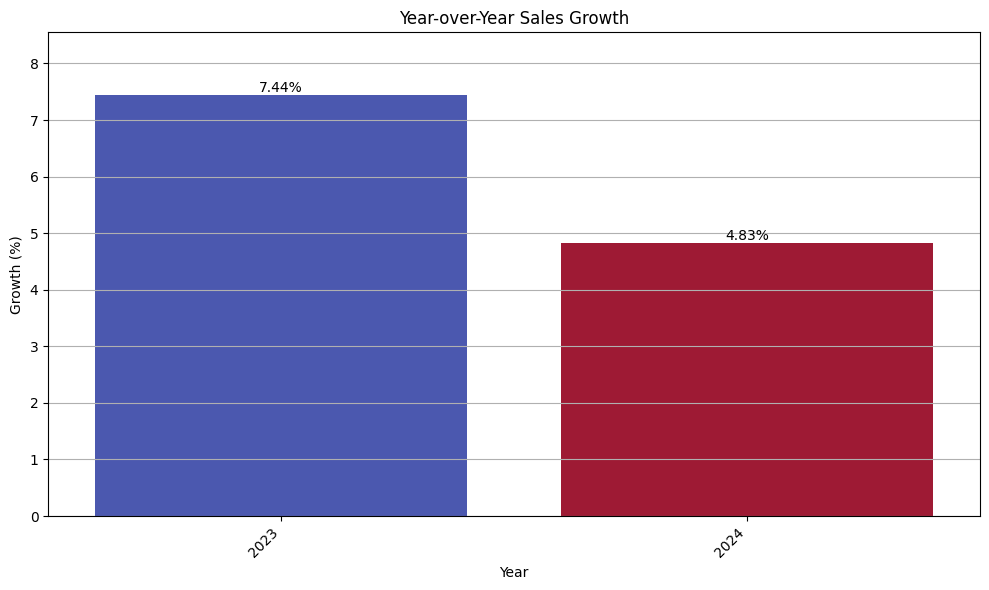

In [ ]:
#chart for Compare Year-over-Year (YoY) sales growth.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=yoy_growth.index,
    y=yoy_growth.values,
    palette='coolwarm',
    hue=yoy_growth.index,
    legend=False
)

# Add percentage labels on top of bars
for i, value in enumerate(yoy_growth.values):
    ax.text(
        i,
        value,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Year-over-Year Sales Growth')
plt.xlabel('Year')
plt.ylabel('Growth (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

# Add some space above bars
plt.ylim(min(0, yoy_growth.min()) * 1.1, yoy_growth.max() * 1.15)

plt.tight_layout()
plt.show()

In [ ]:
# Extract the day of the week (Monday=0, Sunday=6)

df['DayOfWeek'] = df['Date'].dt.dayofweek

# Calculate total sales for each day of the week
sales_by_day_of_week = df.groupby('DayOfWeek')['Amount'].sum()

# Map day numbers to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_by_day_of_week.index = sales_by_day_of_week.index.map(lambda x: day_names[x])

display(sales_by_day_of_week)

,Amount
DayOfWeek,
Monday,2322538.78
Tuesday,2775047.84
Wednesday,3043032.95
Thursday,4052553.28
Friday,3750049.65
Saturday,2545771.28
Sunday,1302578.08


In [ ]:
# Identify the day with the highest sales
highest_sales_day = sales_by_day_of_week.idxmax()
highest_sales_day_amount = sales_by_day_of_week.max()

print(f"The day of the week with the highest sales is {highest_sales_day} with a total of ${highest_sales_day_amount:,.2f}.")

The day of the week with the highest sales is Thursday with a total of $4,052,553.28.


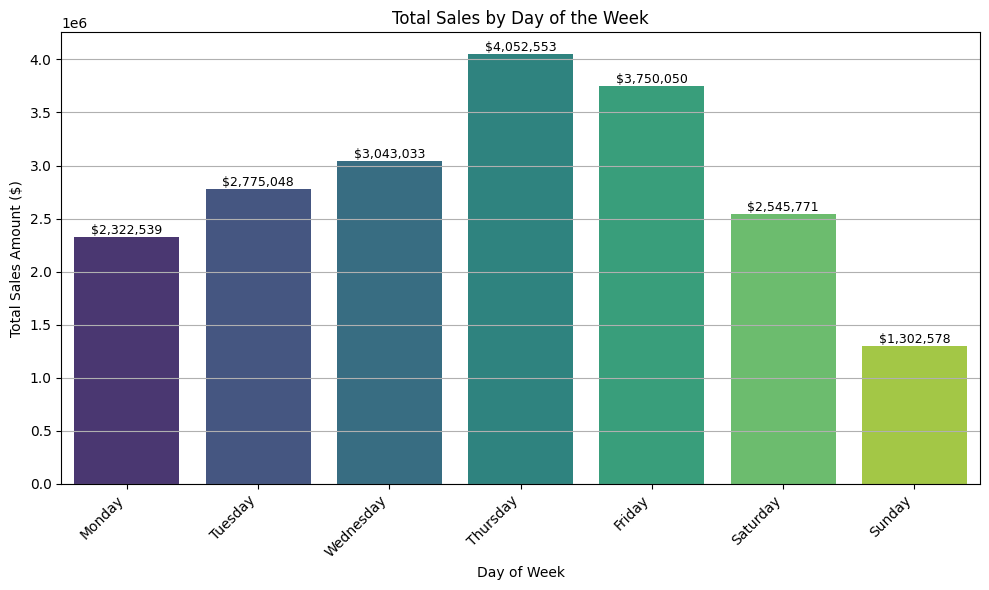

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=sales_by_day_of_week.index,
    y=sales_by_day_of_week.values,
    palette='viridis',
    hue=sales_by_day_of_week.index,
    legend=False
)

# Add values on top of bars
for i, value in enumerate(sales_by_day_of_week.values):
    ax.text(
        i,
        value,
        f'${value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Total Sales by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()